# Clusterização com scikit-learn

Este notebook apresenta preparação de dados orientada a distância, K-Means, DBSCAN e PCA. Clusterização não usa uma variável-alvo no ajuste: os grupos precisam ser avaliados por geometria, estabilidade e interpretação no domínio. Veja também o [guia do módulo](../docs/003__CLUSTERING.md).

## Preparação e imports

A preparação define o que é proximidade. Em particular, K-Means e DBSCAN são sensíveis à escala: uma coluna medida em milhares pode dominar outra medida em dezenas. `StandardScaler` é um ponto de partida quando as features numéricas devem ter importância comparável.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import load_wine, make_blobs, make_moons
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
pd.set_option('display.float_format', lambda value: f'{value:.3f}')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

In [2]:
X_exemplo = pd.DataFrame({'idade': [22, 35, 48], 'renda_anual': [35_000, 80_000, 120_000]})
X_exemplo_scaled = pd.DataFrame(
    StandardScaler().fit_transform(X_exemplo), columns=X_exemplo.columns
)
print('Unidades originais:')
display(X_exemplo)
print('Após StandardScaler:')
display(X_exemplo_scaled)

Unidades originais:


,idade,renda_anual
0,22,35000
1,35,80000
2,48,120000


Após StandardScaler:


,idade,renda_anual
0,-1.225,-1.248
1,0.000,0.048
2,1.225,1.200


## 1. K-Means: grupos compactos

K-Means escolhe `k` centróides e alterna entre atribuir cada ponto ao centróide mais próximo e recalcular esses centróides. É apropriado para grupos compactos e aproximadamente esféricos. A inércia sempre cai com `k`; por isso ela deve ser combinada com silhouette e com a utilidade dos segmentos.

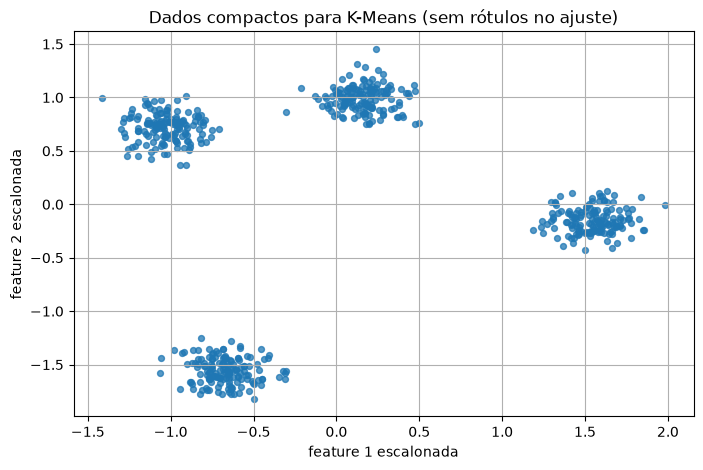

,k,inercia,silhouette
0,2,624.523,0.573
1,3,131.709,0.769
2,4,20.445,0.847
3,5,18.469,0.719
4,6,16.616,0.571
5,7,14.809,0.447
6,8,12.996,0.330


In [3]:
X_blobs, _ = make_blobs(
    n_samples=600, centers=4, cluster_std=0.75, random_state=RANDOM_STATE
)
X_blobs_scaled = StandardScaler().fit_transform(X_blobs)

plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], s=18, alpha=0.75)
plt.title('Dados compactos para K-Means (sem rótulos no ajuste)')
plt.xlabel('feature 1 escalonada')
plt.ylabel('feature 2 escalonada')
plt.show()

resultados_k = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels_k = model.fit_predict(X_blobs_scaled)
    resultados_k.append({
        'k': k, 'inercia': model.inertia_,
        'silhouette': silhouette_score(X_blobs_scaled, labels_k),
    })

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k)

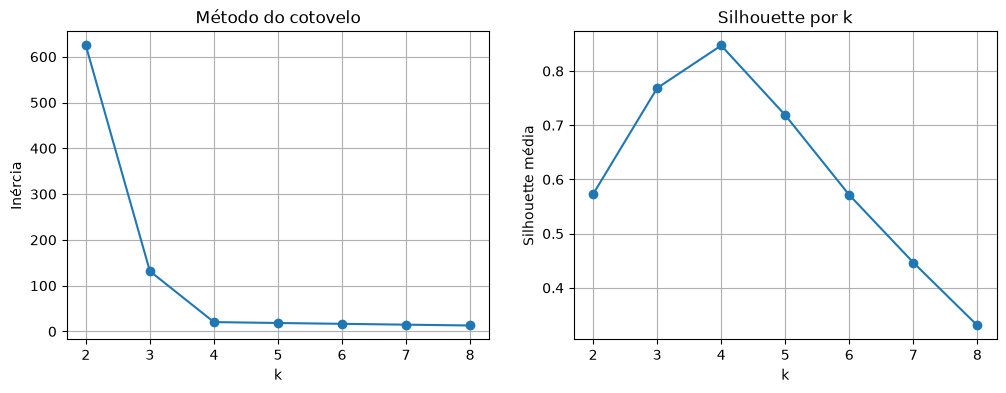

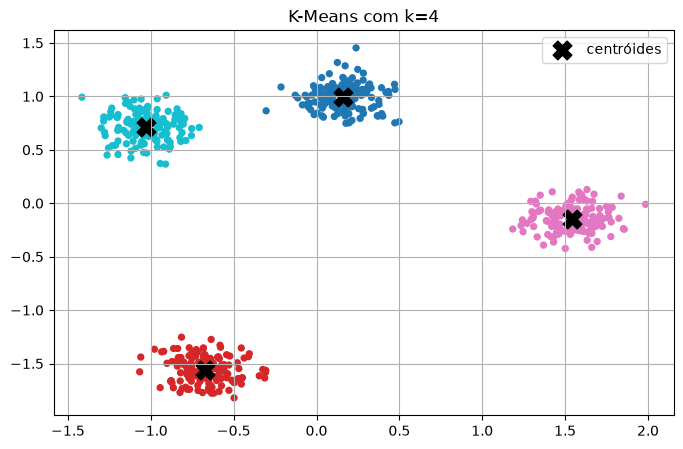

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(resultados_k['k'], resultados_k['inercia'], marker='o')
axes[0].set(title='Método do cotovelo', xlabel='k', ylabel='Inércia')
axes[1].plot(resultados_k['k'], resultados_k['silhouette'], marker='o')
axes[1].set(title='Silhouette por k', xlabel='k', ylabel='Silhouette média')
plt.show()

kmeans_blobs = KMeans(n_clusters=4, n_init=20, random_state=RANDOM_STATE)
labels_blobs = kmeans_blobs.fit_predict(X_blobs_scaled)
plt.scatter(X_blobs_scaled[:, 0], X_blobs_scaled[:, 1], c=labels_blobs, cmap='tab10', s=18)
plt.scatter(*kmeans_blobs.cluster_centers_.T, c='black', marker='X', s=180, label='centróides')
plt.title('K-Means com k=4')
plt.legend()
plt.show()

Neste conjunto, o cotovelo e silhouette sustentam `k=4`. Em dados reais, a decisão também deve verificar tamanho dos grupos, estabilidade sob reamostragem e se os perfis encontrados respondem a uma pergunta do domínio.

## 2. DBSCAN: formas arbitrárias e ruído

DBSCAN conecta regiões densas. Um ponto é núcleo se tiver pelo menos `min_samples` observações na vizinhança de raio `eps`; pontos não conectados a regiões densas recebem rótulo `-1` de ruído. Assim, ele não exige o número de clusters, mas `eps` só tem significado depois de fixar a escala.

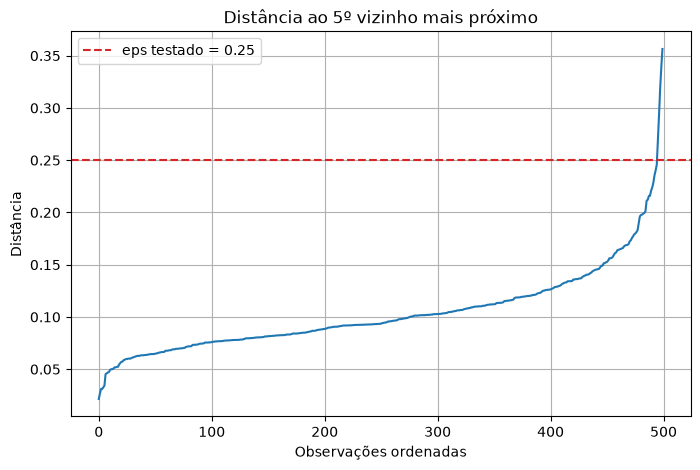

In [5]:
X_moons, _ = make_moons(n_samples=500, noise=0.07, random_state=RANDOM_STATE)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples).fit(X_moons_scaled)
distances, _ = neighbors.kneighbors(X_moons_scaled)
k_distances = np.sort(distances[:, -1])

plt.plot(k_distances)
plt.axhline(0.25, color='tab:red', linestyle='--', label='eps testado = 0.25')
plt.title('Distância ao 5º vizinho mais próximo')
plt.xlabel('Observações ordenadas')
plt.ylabel('Distância')
plt.legend()
plt.show()

Clusters encontrados: 2
Pontos de ruído: 0 (0.0%)


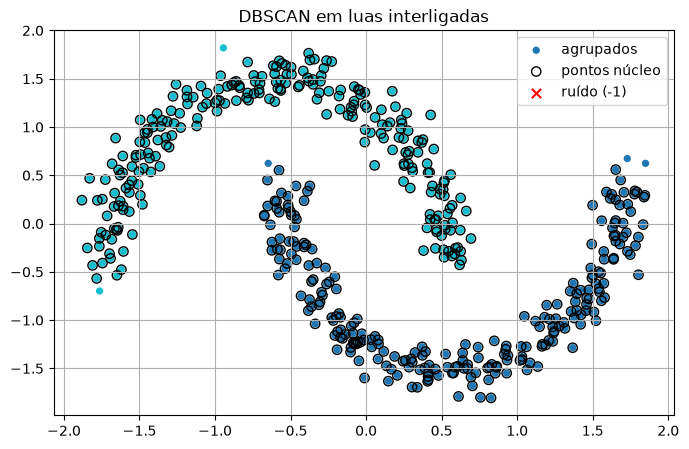

In [6]:
dbscan = DBSCAN(eps=0.25, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_moons_scaled)
ruido = labels_dbscan == -1
cores = np.zeros(len(labels_dbscan), dtype=bool)
cores[dbscan.core_sample_indices_] = True
n_clusters = len(set(labels_dbscan)) - int(-1 in labels_dbscan)
print(f'Clusters encontrados: {n_clusters}')
print(f'Pontos de ruído: {ruido.sum()} ({ruido.mean():.1%})')

plt.scatter(X_moons_scaled[~ruido, 0], X_moons_scaled[~ruido, 1],
            c=labels_dbscan[~ruido], cmap='tab10', s=18, label='agrupados')
plt.scatter(X_moons_scaled[cores, 0], X_moons_scaled[cores, 1],
            facecolors='none', edgecolors='black', s=45, label='pontos núcleo')
plt.scatter(X_moons_scaled[ruido, 0], X_moons_scaled[ruido, 1],
            c='red', marker='x', s=45, label='ruído (-1)')
plt.title('DBSCAN em luas interligadas')
plt.legend()
plt.show()

DBSCAN representa bem as duas luas, cenário onde K-Means tende a falhar por depender de centróides. Ao avaliar DBSCAN, reporte a proporção de ruído junto de qualquer silhouette; rotular quase todos os pontos como `-1` não é uma boa solução. Em alta dimensionalidade ou com densidades muito diferentes, o algoritmo pode ser instável.

## 3. PCA e K-Means no Wine

`load_wine` tem 13 features numéricas em escalas distintas. O pipeline a seguir imputa a mediana e escala os dados. A PCA que preserva 95% da variância é uma alternativa para reduzir redundância; PCA preserva variância, não uma garantia de preservar clusters.

In [7]:
wine = load_wine(as_frame=True)
X_wine = wine.data.copy()
y_wine_referencia = wine.target.copy()  # não usar no ajuste

print('Observações:', X_wine.shape[0], '| Features:', X_wine.shape[1])
print('Valores ausentes:', X_wine.isna().sum().sum())
display(X_wine.describe().T[['mean', 'std', 'min', 'max']])

preparacao_wine = make_pipeline(SimpleImputer(strategy='median'), StandardScaler())
X_wine_scaled = preparacao_wine.fit_transform(X_wine)
pca_95 = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_wine_pca_95 = pca_95.fit_transform(X_wine_scaled)
print('Componentes para 95% da variância:', pca_95.n_components_)
print(f'Variância preservada: {pca_95.explained_variance_ratio_.sum():.1%}')

Observações: 178 | Features: 13
Valores ausentes: 0


,mean,std,min,max
alcohol,13.001,0.812,11.030,14.830
malic_acid,2.336,1.117,0.740,5.800
ash,2.367,0.274,1.360,3.230
alcalinity_of_ash,19.495,3.340,10.600,30.000
magnesium,99.742,14.282,70.000,162.000
total_phenols,2.295,0.626,0.980,3.880
flavanoids,2.029,0.999,0.340,5.080
nonflavanoid_phenols,0.362,0.124,0.130,0.660
proanthocyanins,1.591,0.572,0.410,3.580
color_intensity,5.058,2.318,1.280,13.000


Componentes para 95% da variância: 10
Variância preservada: 96.2%


In [8]:
comparacao_pca = []
for nome, dados in [('escalonado', X_wine_scaled), ('PCA 95%', X_wine_pca_95)]:
    model = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(dados)
    comparacao_pca.append({
        'representacao': nome, 'dimensoes': dados.shape[1],
        'silhouette': silhouette_score(dados, labels),
        'tamanhos': np.bincount(labels).tolist(),
    })
display(pd.DataFrame(comparacao_pca))

# Inércia não é comparável entre representações com variância/dimensão diferentes.
kmeans_wine = KMeans(n_clusters=3, n_init=20, random_state=RANDOM_STATE)
labels_wine = kmeans_wine.fit_predict(X_wine_scaled)

,representacao,dimensoes,silhouette,tamanhos
0,escalonado,13,0.285,"[65, 51, 62]"
1,PCA 95%,10,0.299,"[65, 51, 62]"


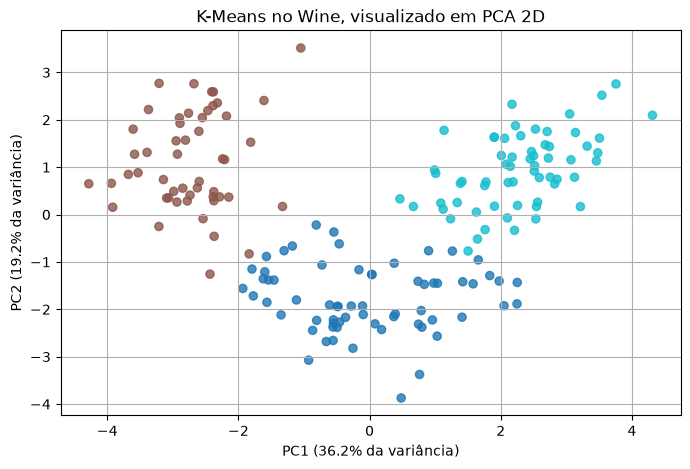

Tamanho dos clusters:


cluster
0    65
1    51
2    62
Name: count, dtype: int64

Médias nas unidades originais:


cluster,0,1,2
alcohol,12.250,13.130,13.680
malic_acid,1.900,3.310,2.000
ash,2.230,2.420,2.470
alcalinity_of_ash,20.060,21.240,17.460
magnesium,92.740,98.670,107.970
total_phenols,2.250,1.680,2.850
flavanoids,2.050,0.820,3.000
nonflavanoid_phenols,0.360,0.450,0.290
proanthocyanins,1.620,1.150,1.920
color_intensity,2.970,7.230,5.450


In [9]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_wine_2d = pca_2d.fit_transform(X_wine_scaled)
plt.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=labels_wine, cmap='tab10', s=35, alpha=0.8)
plt.title('K-Means no Wine, visualizado em PCA 2D')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} da variância)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} da variância)')
plt.show()

perfil_wine = X_wine.copy()
perfil_wine['cluster'] = labels_wine
print('Tamanho dos clusters:')
display(perfil_wine['cluster'].value_counts().sort_index())
print('Médias nas unidades originais:')
display(perfil_wine.groupby('cluster').mean().T.round(2))

O gráfico é somente uma projeção 2D: o K-Means foi ajustado nas 13 features escalonadas. A interpretação deve voltar às unidades originais, como na tabela de médias. Identificadores de cluster são arbitrários: `0` não é melhor nem anterior a `1`.

In [10]:
# Avaliação externa didática: as classes conhecidas não participaram de PCA nem de K-Means.
ari = adjusted_rand_score(y_wine_referencia, labels_wine)
print(f'ARI contra classes de referência, após o ajuste: {ari:.3f}')

ARI contra classes de referência, após o ajuste: 0.897


## Conclusões

- A seleção e a escala das features definem os grupos possíveis.
- K-Means é uma baseline forte para grupos compactos e um `k` plausível.
- DBSCAN permite formas arbitrárias e ruído, mas requer análise cuidadosa de `eps`, `min_samples` e dimensionalidade.
- Use PCA para reduzir muitas features correlacionadas ou para visualização; compare a solução com e sem redução e mantenha a interpretação no espaço original.
- Inércia, silhouette, estabilidade e conhecimento de domínio se complementam; nenhuma métrica isolada torna um cluster útil.